# Comparación temporal entre AAXJ y el clúster Asia

Este notebook construye una **cartera sintética equiponderada** con los fondos del clúster candidato Asia y compara su evolución frente al ETF **AAXJ**.

Supuestos metodológicos:

- La cartera del clúster se construye con **retornos diarios equiponderados**.
- Se usan los fondos exportados en `fondos_candidatos_part2.csv`, es decir, exactamente el universo seleccionado en la Parte 2.

In [1]:
from pathlib import Path
import pickle
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'src' else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT / 'src'
DATASET_DIR = PROJECT_ROOT / 'dataset'

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from aaxj_feature_builder import PRACTICE_END, PRACTICE_START, fetch_aaxj_total_return_series

sns.set_theme(style='whitegrid')

candidate_path = DATASET_DIR / 'fondos_candidatos_part2.csv'
navs_path = DATASET_DIR / 'navs.pickle'

candidate_path, navs_path

(WindowsPath('C:/Users/rvill/Desktop/MIAX/3 Inteligencia Artificial/26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó/Taller ML/dataset/fondos_candidatos_part2.csv'),
 WindowsPath('C:/Users/rvill/Desktop/MIAX/3 Inteligencia Artificial/26 - 03 - 20, 21, 27 y 28 de marzo. Machine Learning Supervisado y Machine Learning No Supervisado. Pedro Ramó/Taller ML/dataset/navs.pickle'))

## Carga de fondos candidatos y series NAV

In [2]:
candidate_funds = pd.read_csv(candidate_path)
candidate_ids = candidate_funds['allfunds_id'].dropna().astype(int).tolist()

with open(navs_path, 'rb') as f:
    navs_dict = pickle.load(f)

print('Fondos candidatos en el clúster:', len(candidate_ids))
print('Fondos disponibles en navs_dict:', len([fid for fid in candidate_ids if fid in navs_dict]))
display(candidate_funds[['allfunds_id', 'isin', 'name_last', 'cluster_kmeans', 'beta_mkt']].head())

C:\Users\rvill\AppData\Local\Temp\ipykernel_5616\3588389128.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  navs_dict = pickle.load(f)


Fondos candidatos en el clúster: 7168
Fondos disponibles en navs_dict: 7168


,allfunds_id,isin,name_last,cluster_kmeans,beta_mkt
0,7681,LU0256332296,"SCHRODER ISF GLOBAL ENERGY ""A1""",0,1.792090
1,7680,LU0256331488,"SCHRODER ISF GLOBAL E ""A"" (USD) A",0,1.792027
2,7683,LU0256331728,"SCHRODER ISF GLOBAL ENERGY ""C""",0,1.791521
3,7682,LU0256331561,"SCHRODER ISF GLOBAL ENERGY ""B""",0,1.791092
4,147257,LU0671501558,"SCHRODER ISF GLOBAL ENERGY ""A"" (EURHDG)",0,1.790507


## Construcción de la cartera sintética del clúster

Se calcula el retorno diario de cada fondo y, para cada fecha, se toma la media simple de los fondos disponibles. Después se acumula esa serie y se reescala a base 100.

In [3]:
def extract_fund_returns(fund_id, navs_dict):
    df = navs_dict.get(fund_id)
    if df is None:
        return None

    nav_col = 'nav' if 'nav' in df.columns else None
    if nav_col is None:
        return None

    series = pd.to_numeric(df[nav_col], errors='coerce').copy()
    series.index = pd.to_datetime(df.index, errors='coerce')
    series = series.dropna().sort_index()
    series = series[~series.index.duplicated(keep='last')]
    series = series.loc[(series.index.date >= PRACTICE_START) & (series.index.date <= PRACTICE_END)]

    if series.shape[0] < 252:
        return None

    returns = series.pct_change().dropna()
    returns.name = fund_id
    return returns


returns_list = []
missing_ids = []

for fund_id in candidate_ids:
    ret = extract_fund_returns(fund_id, navs_dict)
    if ret is None:
        missing_ids.append(fund_id)
    else:
        returns_list.append(ret)

cluster_returns_df = pd.concat(returns_list, axis=1).sort_index()
cluster_returns_df = cluster_returns_df.loc[(cluster_returns_df.index.date >= PRACTICE_START) & (cluster_returns_df.index.date <= PRACTICE_END)]

cluster_portfolio_returns = cluster_returns_df.mean(axis=1, skipna=True).dropna()
cluster_index = 100 * (1 + cluster_portfolio_returns).cumprod()
cluster_index.name = 'Cluster Asia (cartera equiponderada)'

print('Fondos con retornos utilizables:', len(returns_list))
print('Fondos descartados o no encontrados:', len(missing_ids))
print('Fechas de la cartera sintética:', cluster_index.index.min().date(), '->', cluster_index.index.max().date())
print('Nº medio de fondos disponibles por día:', round(cluster_returns_df.notna().sum(axis=1).mean(), 1))

Fondos con retornos utilizables: 7168
Fondos descartados o no encontrados: 0
Fechas de la cartera sintética: 2016-01-06 -> 2021-07-16
Nº medio de fondos disponibles por día: 4402.9


## Serie del ETF AAXJ

Se usa la misma fuente externa oficial ya utilizada para generar las features del ETF.

In [4]:
aaxj_points = fetch_aaxj_total_return_series()
aaxj_df = pd.DataFrame({
    'Date': pd.to_datetime([point.dt for point in aaxj_points]),
    'aaxj_raw': [point.value for point in aaxj_points],
}).sort_values('Date')

aaxj_df['AAXJ'] = 100 * aaxj_df['aaxj_raw'] / aaxj_df['aaxj_raw'].iloc[0]
aaxj_df = aaxj_df.set_index('Date')

print('Fechas ETF AAXJ:', aaxj_df.index.min().date(), '->', aaxj_df.index.max().date())
display(aaxj_df.head())

Fechas ETF AAXJ: 2016-01-05 -> 2021-07-16


,aaxj_raw,AAXJ
Date,,
2016-01-05,11905.551803,100.000000
2016-01-06,11780.865275,98.952703
2016-01-07,11464.822298,96.298118
2016-01-08,11522.389244,96.781648
2016-01-11,11262.854020,94.601697


## Alineación temporal y gráfico comparativo

,Cluster Asia (cartera equiponderada),AAXJ
2016-01-06,100.000000,100.000000
2016-01-07,97.844299,97.317319
2016-01-08,97.466986,97.805967
2016-01-11,96.205434,95.602944
2016-01-12,96.173467,95.332152


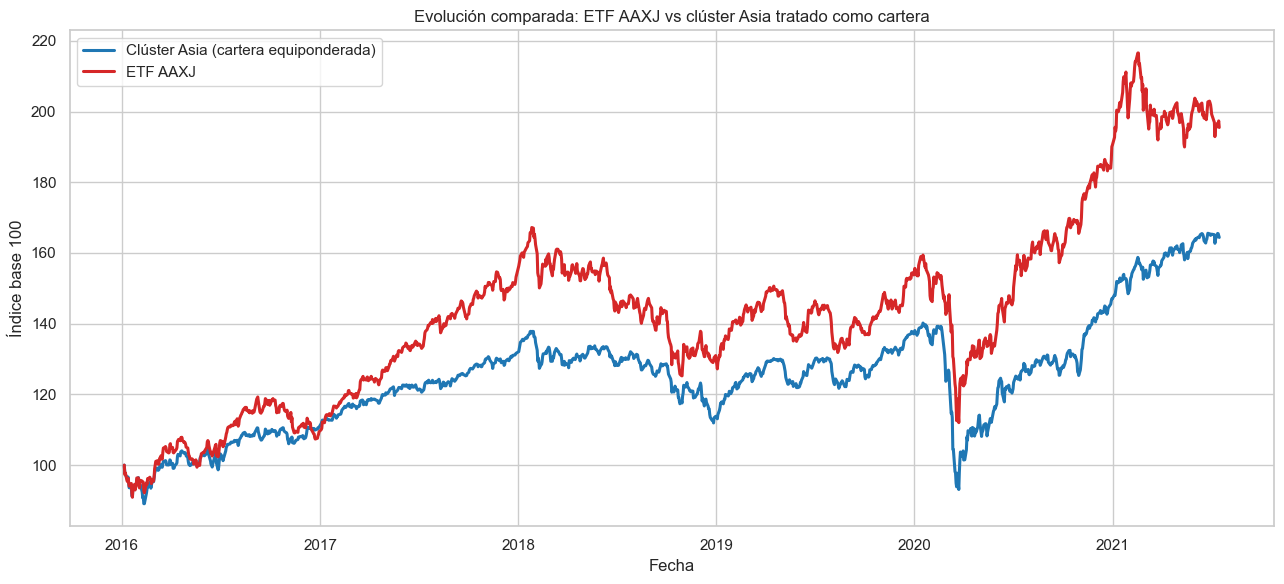

In [5]:
comparison_df = pd.concat([
    cluster_index,
    aaxj_df['AAXJ'],
], axis=1, join='inner').dropna()

# Rebase común para asegurar comparabilidad exacta en la primera fecha compartida.
comparison_df['Cluster Asia (cartera equiponderada)'] = 100 * comparison_df['Cluster Asia (cartera equiponderada)'] / comparison_df['Cluster Asia (cartera equiponderada)'].iloc[0]
comparison_df['AAXJ'] = 100 * comparison_df['AAXJ'] / comparison_df['AAXJ'].iloc[0]

display(comparison_df.head())

plt.figure(figsize=(13, 6))
plt.plot(comparison_df.index, comparison_df['Cluster Asia (cartera equiponderada)'], label='Clúster Asia (cartera equiponderada)', linewidth=2.2, color='#1f77b4')
plt.plot(comparison_df.index, comparison_df['AAXJ'], label='ETF AAXJ', linewidth=2.2, color='#d62728')
plt.title('Evolución comparada: ETF AAXJ vs clúster Asia tratado como cartera')
plt.xlabel('Fecha')
plt.ylabel('Índice base 100')
plt.legend()
plt.tight_layout()
plt.show()

## Resumen rápido de resultados

In [6]:
summary_df = pd.DataFrame({
    'serie': ['Clúster Asia (cartera equiponderada)', 'ETF AAXJ'],
    'fecha_inicio': [comparison_df.index.min().date(), comparison_df.index.min().date()],
    'fecha_fin': [comparison_df.index.max().date(), comparison_df.index.max().date()],
    'valor_inicial': [comparison_df.iloc[0, 0], comparison_df.iloc[0, 1]],
    'valor_final': [comparison_df.iloc[-1, 0], comparison_df.iloc[-1, 1]],
    'rentabilidad_acumulada': [comparison_df.iloc[-1, 0] / comparison_df.iloc[0, 0] - 1, comparison_df.iloc[-1, 1] / comparison_df.iloc[0, 1] - 1],
})

display(summary_df)

,serie,fecha_inicio,fecha_fin,valor_inicial,valor_final,rentabilidad_acumulada
0,Clúster Asia (cartera equiponderada),2016-01-06,2021-07-16,100.0,164.400847,0.644008
1,ETF AAXJ,2016-01-06,2021-07-16,100.0,195.503397,0.955034


## Nota metodológica

Este contraste no replica una cartera invertible exacta, sino una **aproximación analítica** del comportamiento del clúster. La comparación es útil para validar si el grupo seleccionado se mueve de forma parecida al ETF test, pero conviene mencionar en la práctica que:

- la cartera es equiponderada,
- no se aplican costes ni rebalanceos complejos,
- y el clúster puede contener múltiples share classes de un mismo producto.